In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/05_category_inflows.csv")

df.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [3]:
# Check missing values
df.isnull().sum()

# Remove duplicates
df = df.drop_duplicates()

# Check data types
df.dtypes

# Save cleaned dataset
df.to_csv(
    "../data/processed/dataset5_cleaned.csv",
    index=False
)

In [3]:
df.shape

(144, 3)

In [4]:
df.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB


In [6]:
df.describe()

,net_inflow_crore
count,144.000000
mean,6473.881944
std,9718.335947
min,437.000000
25%,1801.250000
50%,4148.000000
75%,5304.000000
max,41952.000000


In [7]:
df["month"] = pd.to_datetime(df["month"])

df.dtypes

month               datetime64[us]
category                       str
net_inflow_crore           float64
dtype: object

In [8]:
df.isnull().sum()

month               0
category            0
net_inflow_crore    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["category"].nunique()

12

In [11]:
df["category"].unique()

<StringArray>
[        'Large Cap',           'Mid Cap',         'Small Cap',
         'Flexi Cap',   'Large & Mid Cap',              'ELSS',
      'Value/Contra', 'Sectoral/Thematic',            'Liquid',
    'Short Duration',              'Gilt',            'Hybrid']
Length: 12, dtype: str

In [13]:
df["month"].min(), df["month"].max()

(Timestamp('2024-04-01 00:00:00'), Timestamp('2025-03-01 00:00:00'))

In [14]:
category_total = (
    df.groupby("category")["net_inflow_crore"]
    .sum()
    .sort_values(ascending=False)
)

category_total

category
Liquid               451275.0
Sectoral/Thematic    103829.0
Flexi Cap             63989.0
Large & Mid Cap       57752.0
Short Duration        55530.0
Mid Cap               55312.0
Small Cap             46596.0
Hybrid                38868.0
Large Cap             25633.0
Value/Contra          16980.0
Gilt                  10395.0
ELSS                   6080.0
Name: net_inflow_crore, dtype: float64

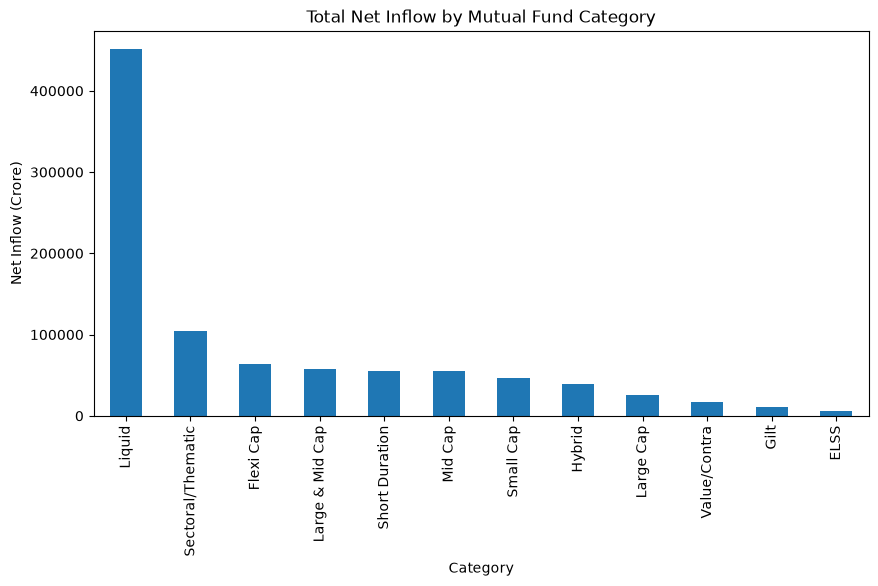

In [15]:
plt.figure(figsize=(10,5))

category_total.plot(
    kind="bar"
)

plt.title("Total Net Inflow by Mutual Fund Category")
plt.xlabel("Category")
plt.ylabel("Net Inflow (Crore)")

plt.xticks(rotation=90)

plt.show()

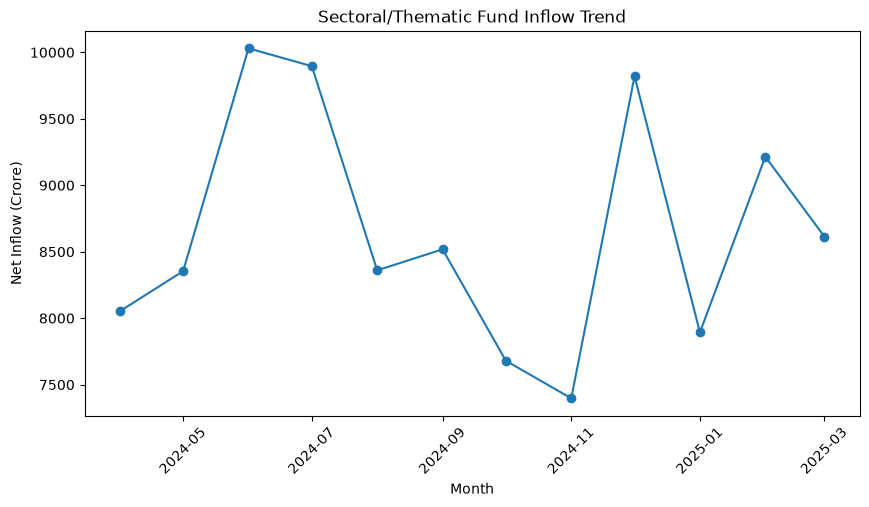

In [16]:
sectoral = df[df["category"]=="Sectoral/Thematic"]

plt.figure(figsize=(10,5))

plt.plot(
    sectoral["month"],
    sectoral["net_inflow_crore"],
    marker="o"
)

plt.title("Sectoral/Thematic Fund Inflow Trend")
plt.xlabel("Month")
plt.ylabel("Net Inflow (Crore)")

plt.xticks(rotation=45)

plt.show()

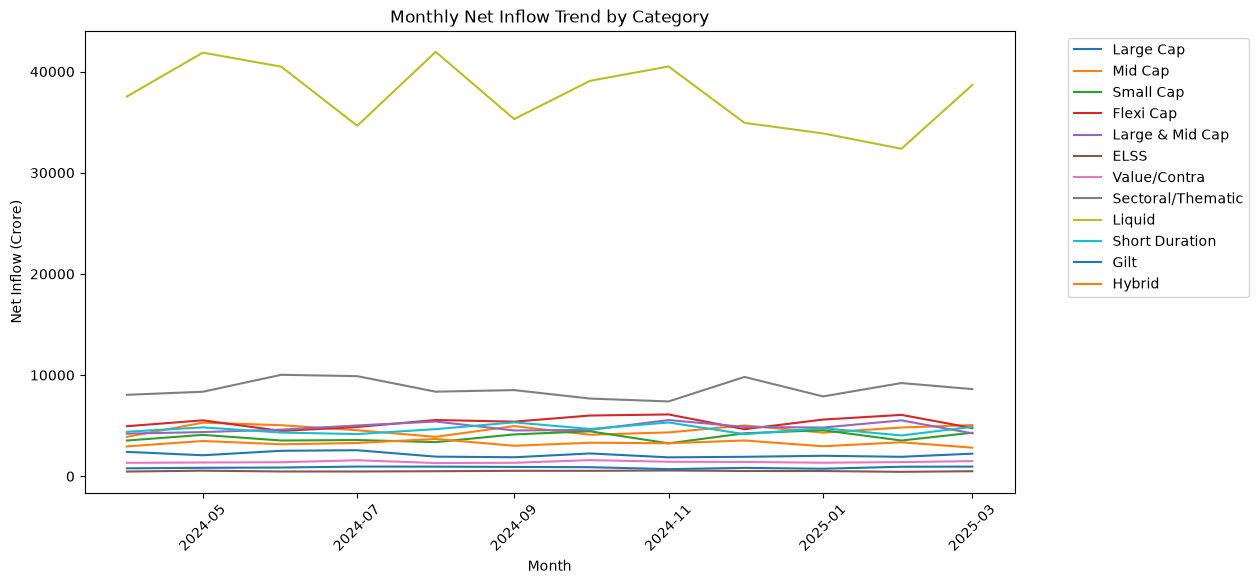

In [17]:
plt.figure(figsize=(12,6))

for category in df["category"].unique():

    temp = df[df["category"] == category]

    plt.plot(
        temp["month"],
        temp["net_inflow_crore"],
        label=category
    )


plt.title("Monthly Net Inflow Trend by Category")
plt.xlabel("Month")
plt.ylabel("Net Inflow (Crore)")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.xticks(rotation=45)

plt.show()

In [18]:
df.loc[
    df["net_inflow_crore"].idxmax()
]

month               2024-08-01 00:00:00
category                         Liquid
net_inflow_crore                41952.0
Name: 56, dtype: object

In [19]:
df.loc[
    df["net_inflow_crore"].idxmin()
]

month               2025-02-01 00:00:00
category                           ELSS
net_inflow_crore                  437.0
Name: 125, dtype: object

In [20]:
monthly_total = (
    df.groupby("month")["net_inflow_crore"]
    .sum()
)

monthly_total

month
2024-04-01    74526.0
2024-05-01    82661.0
2024-06-01    80911.0
2024-07-01    75608.0
2024-08-01    81601.0
2024-09-01    75865.0
2024-10-01    79180.0
2024-11-01    80323.0
2024-12-01    75943.0
2025-01-01    73417.0
2025-02-01    73631.0
2025-03-01    78573.0
Name: net_inflow_crore, dtype: float64

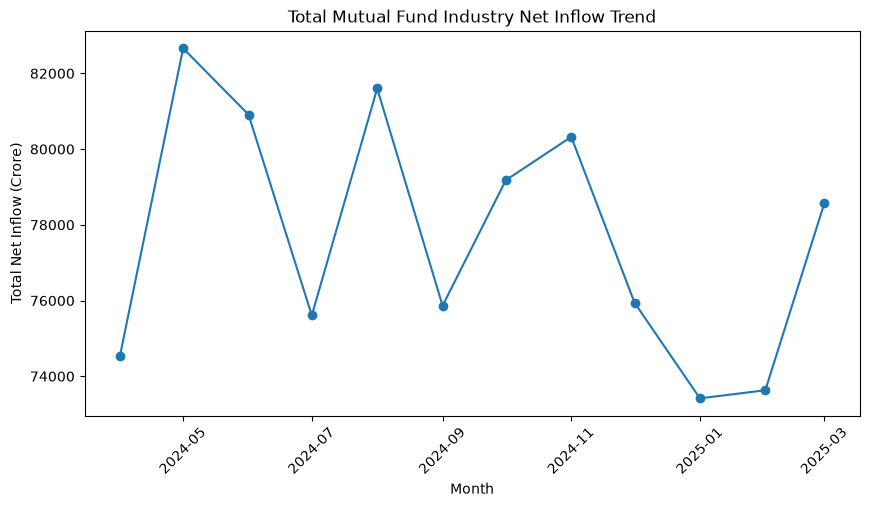

In [21]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_total.index,
    monthly_total.values,
    marker="o"
)

plt.title("Total Mutual Fund Industry Net Inflow Trend")
plt.xlabel("Month")
plt.ylabel("Total Net Inflow (Crore)")

plt.xticks(rotation=45)

plt.show()

# Insights from Category-wise Net Inflow Dataset

## Dataset Overview
- Dataset contains monthly mutual fund category-wise net inflow data.
- Analysis period covers April 2024 to March 2025.
- Total categories analyzed: 12.

## Data Quality
- Month column was converted into datetime format.
- No missing values were observed.
- No duplicate records were found.

## Inflow Analysis
- Liquid funds received the highest net inflows among categories.
- Sectoral/Thematic funds also attracted significant investor interest.
- Equity categories such as Mid Cap, Small Cap and Flexi Cap showed consistent investment activity.

## Key Observation
Investor preference varies across mutual fund categories based on market conditions and investment objectives. Net inflow analysis helps identify popular investment segments.